<a href="https://colab.research.google.com/github/laramutair/Car-Insurance-Claim-Prediction/blob/main/Project_4_Part_1_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [213]:
def plot_importance(importances, top_n=None,  figsize=(8,6)):
    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Importance',
            ylabel='Feature Names',
            title=title)
    ## return ax in case want to continue to update/modify figure
    return ax

In [214]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [215]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [216]:
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [217]:
def plot_categorical_vs_target(df, x, y, figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None, target_type='class'):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)
  # REGRESSION-TARGET PLOT
  if target_type=='reg': #Added if statement here
    # Barplot
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidth=1, edgecolor='black', errorbar=None)
    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                  order=order, hue_order=order, legend=False,
                  edgecolor='white', linewidth=0.5,
                  size=3,zorder=0)
  # CLASSIFICATION-TARGET PLOT # This is the new code for the classification task
  elif target_type=='class':
    ax = sns.histplot(data=temp_df, hue=y, x=x, stat='percent',  multiple='fill')
  # Rotate xlabels
  ax.set_xticks(ax.get_xticks()) # Added this to prevent a bug
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

In [218]:
def plot_numeric_vs_target(df, x, y, figsize=(6,4),
                           target_type='class', estimator='mean',
                           errorbar='ci',sorted=False,ascending=False,
                           **kwargs): # kwargs for sns.regplot

  nulls = df[[x,y]].isna().sum()
  if nulls.sum()>0:
    print(f"- Excluding {nulls.sum()} NaN's")
    # print(nulls)
    temp_df = df.dropna(subset=[x,y,])
  else:
    temp_df = df
  # Create the figure
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if 'reg' in target_type:
    # Calculate the correlation
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]
    # Plot the data
    scatter_kws={'ec':'white','lw':1,'alpha':0.8}
    sns.regplot(data=temp_df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
    ## Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})")

  # CLASSIFICATION-TARGET PLOT
  elif 'class' in target_type:

    # Sort the groups by median/mean
    if sorted == True:

      if estimator == 'median':
        group_vals = temp_df.groupby(y)[x].median()
      elif estimator =='mean':
        group_vals = temp_df.groupby(y)[x].mean()

      ## Sort values
      group_vals = group_vals.sort_values(ascending=ascending)
      order = group_vals.index

    else:
      # Set order to None if not calcualted
      order = None


    # Left Subplot (barplot)
    sns.barplot(data=temp_df, x=y, y=x, order=order,  estimator=estimator,
                errorbar=errorbar, ax=ax, **kwargs)

    # Add title
    ax.set_title(f"{x} vs. {y}")

    # rotate xaxis labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


  # Final Adjustments & return
  fig.tight_layout()
  fig.show()
  return fig, ax

In [ ]:
def build_model(hp):
    model = Sequential()

    model.add(Dense(64, activation='relu', input_shape=(input_shape,)))

    model.add(Dense(
        units=hp.Int('units_2', min_value=16, max_value=128, step=64),
        activation='relu'
    ))

    model.add(Dense(
        units=hp.Int('units_3', min_value=8, max_value=, step=16),
        activation='relu'
    ))

    model.add(Dropout(
        hp.Float('dropout_value', min_value=0.0, max_value=0.5, step=0.1)
    ))

    model.add(Dense(16, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=hp.Choice('optimizer', ['rmsprop', 'nadam', 'adam']),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            metrics.Precision(name='precision'),
            metrics.Recall(name='recall')
        ]
    )
    return model

## Import and LOad Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,  confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import silhouette_score

# Keras
from tensorflow.keras import Sequential
from tensorflow.keras import metrics
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
!pip install keras-tuner -q

import keras_tuner as kt
from keras_tuner import HyperParameters as hp
import os
from sklearn import set_config
set_config(transform_output='pandas')


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sagnik1511/car-insurance-data")

print("Path to dataset files:", path)

In [ ]:
df = pd.read_csv(path + "/Car_Insurance_Claim.csv")
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.describe(include="object")

## Clean Data

### Missing value

In [ ]:
df.isna().sum()

### Drop The ID Column

In [ ]:
df = df.drop(columns='ID')

### Duplicates

In [ ]:
df.duplicated().sum()

In [ ]:
df = df.drop_duplicates(keep='first')

In [ ]:
df.duplicated().sum()

### Check and Fix Data type

In [ ]:
obj_cols =df.astype('object').columns
obj_cols

In [ ]:
df['POSTAL_CODE'].value_counts()

In [ ]:
for col in obj_cols:
    print(f"{col}: {df[col].unique()}")
    print('------------------------------------------------')


In [ ]:
for col in obj_cols:
    print(f"{col}: {df[col].value_counts()}")
    print('------------------------------------------------')

In [ ]:
df['CREDIT_SCORE'] = df['CREDIT_SCORE'].astype(float)

In [ ]:
df['ANNUAL_MILEAGE']=df['ANNUAL_MILEAGE'].astype(float)

### Check for Inconsistent Data

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

In [ ]:
for col in cat_cols:
    print(f'\n{col}: {df[col].unique()}')

In [ ]:
for col in cat_cols:
    df[col] = df[col].str.strip().str.upper()

print('Categorical values standardized (stripped + uppercased)')

## Check Data balance

In [ ]:
df['OUTCOME'].value_counts(normalize=True)

## EDA

### Histogram

In [ ]:
df.hist(bins=30, figsize=(20,20))

### Outcome VS Vechicle Type

In [ ]:
plot_categorical_vs_target(df, x='VEHICLE_TYPE', y='OUTCOME', figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None)

### OutCome Vs Age

In [ ]:
plot_categorical_vs_target(df, x='AGE', y='OUTCOME', figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None)

### OutCome VS Credit Score

- Excluding 970 NaN's


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'CREDIT_SCORE vs. OUTCOME'}, xlabel='OUTCOME', ylabel='CREDIT_SCORE'>)

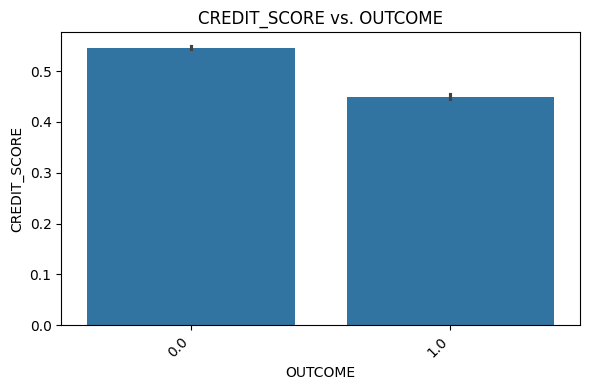

In [221]:
plot_numeric_vs_target(df, x='CREDIT_SCORE', y='OUTCOME', figsize=(6,4),
                       target_type='class', estimator='mean',
                       errorbar='ci',sorted=False,ascending=False)

<Axes: >

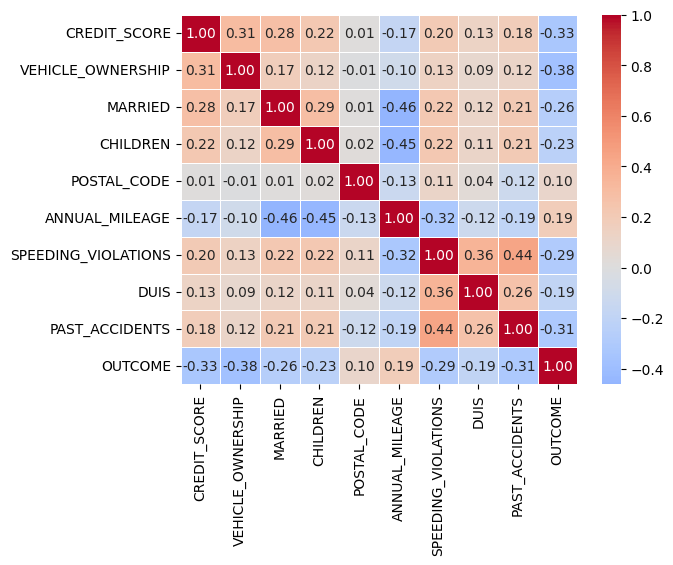

In [222]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0,  linewidths=0.5)


## Preprocess

In [223]:
numeric_col =['CREDIT_SCORE','ANNUAL_MILEAGE','SPEEDING_VIOLATIONS','DUIS','PAST_ACCIDENTS']
ordinal_col = ['AGE','DRIVING_EXPERIENCE','EDUCATION','INCOME','VEHICLE_YEAR']
cat_col = ['GENDER','RACE','VEHICLE_TYPE','VEHICLE_OWNERSHIP','MARRIED','CHILDREN','POSTAL_CODE']

### Procee the numeric cols

In [224]:
df[numeric_col].isna().sum()

,0
CREDIT_SCORE,970
ANNUAL_MILEAGE,954
SPEEDING_VIOLATIONS,0
DUIS,0
PAST_ACCIDENTS,0


In [225]:
X = df.drop(columns='OUTCOME')
y = df['OUTCOME']

In [226]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [227]:
impute  = SimpleImputer(strategy='median')
scaled = StandardScaler()
num_pip = make_pipeline(impute, scaled)
num_tuple=('numeric', num_pip, numeric_col)
num_pip

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

### Cat Columns

In [228]:
df[cat_col].isna().sum()

,0
GENDER,0
RACE,0
VEHICLE_TYPE,0
VEHICLE_OWNERSHIP,0
MARRIED,0
CHILDREN,0
POSTAL_CODE,0


In [229]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_pip = make_pipeline(encoder)
cat_tuple = ('categorical', cat_pip, cat_col)

### Ordianl Columns

In [230]:
df[ordinal_col].isna().sum()

,0
AGE,0
DRIVING_EXPERIENCE,0
EDUCATION,0
INCOME,0
VEHICLE_YEAR,0


In [231]:
ord_encoder = OrdinalEncoder(categories=[
    ['16-25', '26-39', '40-64', '65+'],          # AGE
    ['0-9Y', '10-19Y', '20-29Y', '30Y+'],         # DRIVING_EXPERIENCE
    ['NONE', 'HIGH SCHOOL', 'UNIVERSITY'],         # EDUCATION
    ['POVERTY', 'WORKING CLASS', 'MIDDLE CLASS', 'UPPER CLASS'],  # INCOME
    ['BEFORE 2015', 'AFTER 2015']                  # VEHICLE_YEAR
])
scaler = StandardScaler()
ord_pip = make_pipeline(ord_encoder, scaler)
ord_tuple = ('ordinal', ord_pip, ordinal_col)

In [232]:
preprocessor = ColumnTransformer([num_tuple, cat_tuple, ord_tuple],
                                  verbose_feature_names_out=False)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)   # transform فقط!

print(f"Train shape: {X_train_prep.shape}")
print(f"Test shape:  {X_test_prep.shape}")

Train shape: (7990, 26)
Test shape:  (1998, 26)


In [233]:
model1 = Sequential()
model1.add(Dense(64, activation='relu', input_shape=(X_train_prep.shape[1],)))
model1.add(Dense(1, activation='sigmoid'))
model1.compile(optimizer='adam', loss='binary_crossentropy',  metrics=['accuracy', metrics.Precision(), metrics.Recall()])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [234]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True )

In [235]:
history = model1.fit(
    X_train_prep, y_train,
    validation_split=0.2,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8098 - loss: 0.4160 - precision: 0.7201 - recall: 0.6322 - val_accuracy: 0.8260 - val_loss: 0.3829 - val_precision: 0.7949 - val_recall: 0.6145
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8395 - loss: 0.3507 - precision: 0.7707 - recall: 0.6867 - val_accuracy: 0.8317 - val_loss: 0.3629 - val_precision: 0.7909 - val_recall: 0.6438
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8453 - loss: 0.3357 - precision: 0.7721 - recall: 0.7109 - val_accuracy: 0.8411 - val_loss: 0.3523 - val_precision: 0.7740 - val_recall: 0.7104
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8508 - loss: 0.3281 - precision: 0.7714 - recall: 0.7371 - val_accuracy: 0.8385 - val_loss: 0.3534 - val_precision: 0.8034 - val_recall: 0.6556
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8518 - loss: 0.3227 - precision: 0.7793 - recall: 0.7286 - val_accuracy: 0.8442 - val_loss: 0.

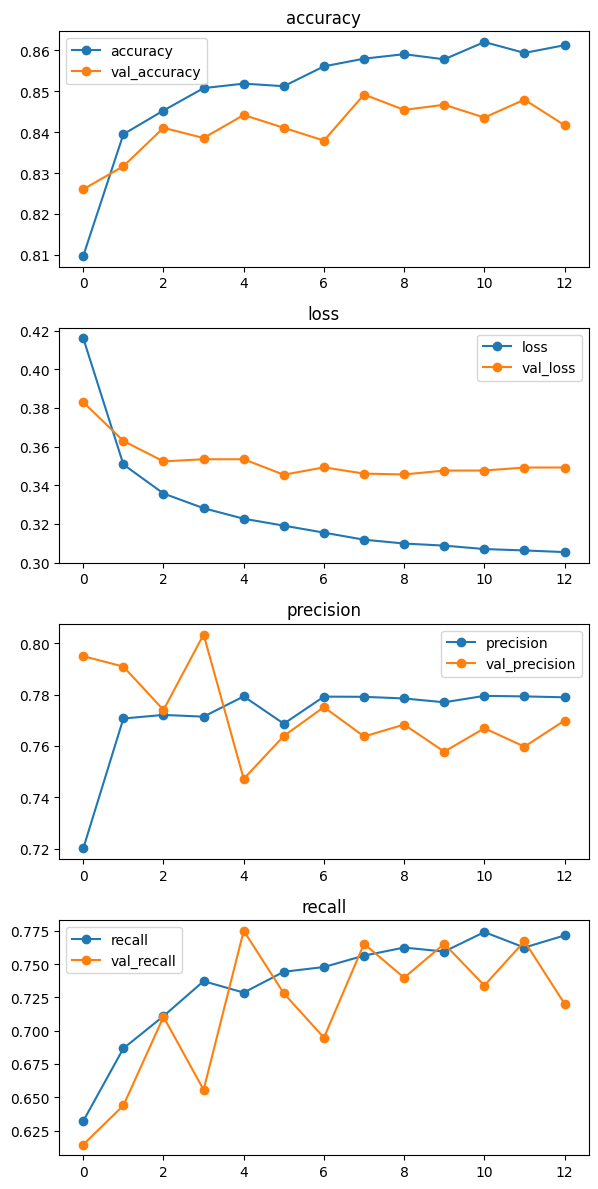

In [236]:
plot_history(history);

In [237]:
y_pred_test = model1.predict(X_test_prep)
y_pred_test[:5]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0.00345408],
       [0.6551837 ],
       [0.5209581 ],
       [0.00716469],
       [0.86009   ]], dtype=float32)

In [238]:
y_pred_test = np.round(y_pred_test)
y_pred_test[:5]

array([[0.],
       [1.],
       [1.],
       [0.],
       [1.]], dtype=float32)

              precision    recall  f1-score   support

         0.0       0.89      0.88      0.89      1367
         1.0       0.75      0.77      0.76       631

    accuracy                           0.85      1998
   macro avg       0.82      0.83      0.83      1998
weighted avg       0.85      0.85      0.85      1998



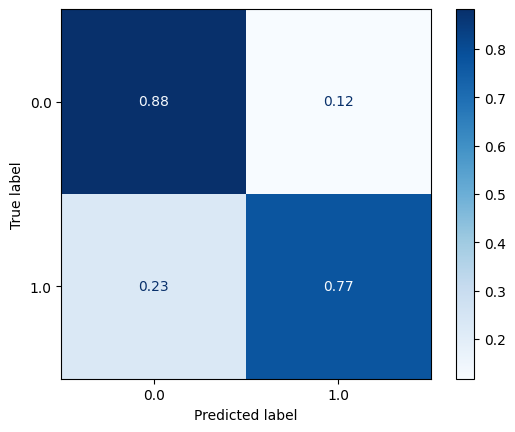

In [239]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues',
                                       normalize='true');

##Keras Tuner Model

In [240]:
folder = 'KerasTuner/'
os.makedirs(folder, exist_ok=True)

In [241]:
input_shape = X_train_prep.shape[1]
input_shape

26

In [242]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    directory=folder,
    overwrite=True,
    seed=42,
    project_name='Car_tuning'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [243]:
early_stop = EarlyStopping(monitor='val_loss', patience=8)

In [ ]:
epochs = 100

tuner.search(
    X_train_prep, y_train,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stop]
)

Trial 12 Complete [00h 00m 07s]
val_accuracy: 0.8360450267791748

Best val_accuracy So Far: 0.8473091125488281
Total elapsed time: 00h 01m 36s

Search: Running Trial #13

Value             |Best Value So Far |Hyperparameter
16                |16                |units_2
8                 |8                 |units_3
0.4               |0.4               |dropout_value
nadam             |nadam             |optimizer
7                 |3                 |tuner/epochs
3                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
1                 |0                 |tuner/round
0001              |None              |tuner/trial_id



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 23 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 4/7


In [ ]:
best_hps = tuner.get_best_hyperparameters()[0]
best_hps.values

In [ ]:
best_model = tuner.get_best_models()[0]
best_model.summary()

In [ ]:
result = best_model.evaluate(X_test_prep, y_test, return_dict=True)
result

## Model by Default Logistic Regression

In [ ]:
lr = LogisticRegression(random_state=42, class_weight='balanced',max_iter=1000)

In [ ]:
lr.fit(X_train_prep, y_train)

In [ ]:
evaluate_classification(lr, X_train_prep, y_train,  X_test_prep, y_test)

## Permutation Importance

In [ ]:
perm_result = permutation_importance(
    lr,
    X_test_prep,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)


In [ ]:
feature_names = preprocessor.get_feature_names_out()

perm_df = pd.DataFrame({
    'Feature'         : feature_names,
    'Importance Mean' : perm_result.importances_mean,
    'Importance Std'  : perm_result.importances_std
}).sort_values('Importance Mean', ascending=False)

In [ ]:
#Show top 10
top10 = perm_df.head(10).reset_index(drop=True)
top10

In [ ]:
plot_categorical_vs_target(df, x='DRIVING_EXPERIENCE', y='OUTCOME', figsize=(6,4),
                       target_type='class')

The plot shows:
   - As driving experience increases, the claim rate drops dramatically. Drivers with 0–9 years of experience file claims at a rate of approximately 62%, while drivers with 30+ years of experience have a claim rate close to 0%. This makes strong business sense, experienced drivers have developed better road awareness and decision-making skills over time. Insurance companies can confidently use driving experience as one of the most reliable indicators of customer risk level.


In [ ]:
plot_categorical_vs_target(df, x='POSTAL_CODE', y='OUTCOME', figsize=(6,4),
                       target_type='class')

In [ ]:
plot_categorical_vs_target(df, x='VEHICLE_YEAR', y='OUTCOME', figsize=(6,4),
                       target_type='class')

In [ ]:
plot_categorical_vs_target(df, x='VEHICLE_OWNERSHIP', y='OUTCOME', figsize=(6,4),
                       target_type='class')

The plot shows:
   - Non-owners are likely renting or borrowing a vehicle, they have less personal financial stake in the car, which may lead to less cautious driving. Insurers should treat non-ownership as a significant risk flag.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ownership_claims = df.groupby('VEHICLE_OWNERSHIP')['OUTCOME'].mean() * 100

bars = ax.bar(
    ['Does Not Own Vehicle (0)', 'Owns Vehicle (1)'],
    ownership_claims.values,
    color=['#EF5350', '#42A5F5'],
    edgecolor='white',
    width=0.45
)

for bar, val in zip(bars, ownership_claims.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Vehicle Ownership vs Insurance Claim Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('Vehicle Ownership', fontsize=11)
ax.set_ylabel('Claim Rate (%)', fontsize=11)
ax.set_ylim(0, ownership_claims.max() * 1.3)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

sns.despine()
plt.tight_layout()
plt.show()

The plot shows:
  - Customers who do not own their vehicle file insurance claims at a rate of 57.9%, compared to only 19.7% for customers who own their vehicle, nearly 3 times higher. This suggests that non-owners, who may be renting or borrowing a car, feel less personal responsibility for the vehicle, which can lead to riskier driving behavior. Insurance companies should treat vehicle non-ownership as a strong risk indicator when pricing premiums.


## Feature Engineering Using KMeans Clustering

In [ ]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_prep)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_prep, labels))

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
axes[0].plot(k_range, silhouettes, marker='o')
axes[0].set_title('Silhouette Scores')
axes[0].set_xticks(k_range)
axes[1].plot(k_range, inertias, marker='o')
axes[1].set_title('Inertia')
axes[1].set_xticks(k_range);

### Apply KMeans

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

train_clusters = kmeans.fit_predict(X_train_prep)
test_clusters = kmeans.predict(X_test_prep)

In [ ]:
X_train_kmeans = pd.concat([
    pd.DataFrame(X_train_prep.values, columns=feature_names),
    pd.DataFrame(train_clusters, columns=['CLUSTER'])
], axis=1)

X_test_kmeans = pd.concat([
    pd.DataFrame(X_test_prep.values, columns=feature_names),
    pd.DataFrame(test_clusters, columns=['CLUSTER'])
], axis=1)

In [ ]:
feature_names_kmeans = list(feature_names) + ['CLUSTER']

print(X_train_kmeans.shape)
print(X_test_kmeans.shape)

In [ ]:
lr_kmeans = LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000)
lr_kmeans.fit(X_train_kmeans, y_train)

print("=== Model WITH KMeans Feature ===")
evaluate_classification(lr_kmeans, X_train_kmeans, y_train,
                                   X_test_kmeans,  y_test)

In [ ]:
log_reg_sel = LogisticRegression(C=1e12, max_iter=1000, random_state=42)

selector = SelectFromModel(log_reg_sel)
selector.fit(X_train_kmeans, y_train)

X_train_selected = selector.transform(X_train_kmeans)
X_test_selected  = selector.transform(X_test_kmeans)

above_threshold   = selector.get_support()
selected_features = list(X_train_kmeans.columns[above_threshold])

print(f"Features before: {X_train_kmeans.shape[1]}")
print(f"Features after: {X_train_selected.shape[1]}")

In [ ]:
# Final model
lr_final = LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000)
lr_final.fit(X_train_selected, y_train)

print("=== Final Model (KMeans + SelectFromModel) ===")
evaluate_classification(lr_final, X_train_selected, y_train,
                                  X_test_selected,  y_test)

In [ ]:
perm_final = permutation_importance(
    lr_final,
    X_test_selected, y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

perm_final_series = pd.Series(
    perm_final.importances_mean,
    index=selected_features
)

plot_importance(perm_final_series, top_n=10)
plt.tight_layout()
plt.show()

## Discussion: Comparison

| Model                          | Accuracy | Recall (1) | Precision (1) | F1 (1) |
|--------------------------------|----------|------------|---------------|--------|
| Baseline LR (balanced)         | 0.83     | 0.85       | 0.69          | 0.76   |
| LR + KMeans (balanced)         | 0.83     | 0.85       | 0.69          | 0.76   |
| Final: KMeans + SelectFromModel| 0.78     | 0.88       | 0.61          | 0.72   |

**Top 10 Features Comparison:**

| Rank | Part 1(LogR)      | Final Model (LogR + Kmean +Selector) |
|------|---------------------------|-------------------------------|
| 1    | DRIVING_EXPERIENCE        | DRIVING_EXPERIENCE            |
| 2    | POSTAL_CODE_10238         | POSTAL_CODE_10238             |
| 3    | VEHICLE_YEAR              | VEHICLE_OWNERSHIP_0.0         |
| 4    | POSTAL_CODE_32765         | POSTAL_CODE_32765             |
| 5    | VEHICLE_OWNERSHIP_0.0     | POSTAL_CODE_21217             |
| 6    | POSTAL_CODE_21217         | POSTAL_CODE_92101             |
| 7    | GENDER_MALE               | —                             |
| 8    | VEHICLE_OWNERSHIP_1.0     | —                             |
| 9    | GENDER_FEMALE             | —                             |
| 10   | ANNUAL_MILEAGE            | —                             |

**Key Observations:**

1. DRIVING_EXPERIENCE is the most important feature in both models,
   confirming it is the strongest predictor of insurance claims.

2. POSTAL_CODE features (10238, 32765, 21217) appear in both models,
   showing that geographic location is a consistent and important risk factor.

3. The Final Model has only 6 selected features vs 10 in Part 1.
   SelectFromModel removed VEHICLE_YEAR, GENDER, VEHICLE_OWNERSHIP_1.0,
   and ANNUAL_MILEAGE as they fell below the coefficient threshold.

4. The CLUSTER feature added by KMeans was also removed by SelectFromModel,
   meaning it did not contribute enough signal for this linear model.

5. Impact of class_weight='balanced':
   Recall for class 1 improved significantly from 0.61 (without balancing)
   to 0.85+ across all models, making the model much better at detecting
   actual insurance claims.